In [ ]:
import os
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================
# CONFIGURATION
# =========================
BASE_PATH = r"E:\Final Project\Final_Dataset\oral\stage2_disease_classification"
OLD_WEIGHTS_PATH = r"E:\Final Project\Final_Dataset\Notebooks\stage2_best_weights.h5"
NEW_WEIGHTS_PATH = r"E:\Final Project\Final_Dataset\Notebooks\stage2_7class_best_weights.h5"
FINAL_MODEL_PATH = r"E:\Final Project\Final_Dataset\Notebooks\stage2_7class_final_model.keras"
FINAL_MODEL_PATH2 = r"E:\Final Project\Final_Dataset\Notebooks\stage2_7class_final_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 8

AUTOTUNE = tf.data.AUTOTUNE

# =========================
# LOAD DATA (Now includes Healthy)
# =========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Total Classes:", num_classes)

# Preprocessing
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y),
                        num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y),
                    num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# =========================
# BUILD MODEL (7 Classes)
# =========================
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Initially freeze entire base
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# =========================
# LOAD OLD 6-CLASS WEIGHTS (Skip Last Layer)
# =========================
model.load_weights(OLD_WEIGHTS_PATH, by_name=True, skip_mismatch=True)
print("✅ Loaded backbone weights (last layer skipped)")

# =========================
# CALLBACKS
# =========================
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    NEW_WEIGHTS_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

# =========================
# PHASE 1 — Train Only Final Layer
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🚀 Phase 1: Training classifier layer only...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# PHASE 2 — Fine-Tune Top Layers
# =========================
base_model.trainable = True

# Freeze lower layers, fine-tune top 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n🔥 Phase 2: Fine-tuning top layers...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

# =========================
# SAVE FINAL MODEL
# =========================
model.save(FINAL_MODEL_PATH)
print("✅ Final 7-class model saved successfully!")
model.save(FINAL_MODEL_PATH2)
print("✅ Final 7-class model saved successfully!2")

In [ ]:
## PART 1 — Environment & Imports

In [16]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import seaborn as sns

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))


TensorFlow Version: 2.13.0
GPU Available: []


In [ ]:
## PART 2 — Configuration

In [28]:
BASE_PATH = r"E:\Final Project\Final_Dataset\oral\disease_classification"

WEIGHTS_PATH = "oral7_best_weights.h5"          # Best weights only
FINAL_MODEL_PATH = "oral7_best_model.keras"     # Full model (recommended)
FINAL_MODEL_PATH_H5 = "oral7_best_model.h5"     # Full model (.h5 format)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
PHASE1_EPOCHS = 6
PHASE2_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
### PART 3 — Dataset Structure Verification

In [30]:
def verify_dataset(base_path):
    print("\nVerifying dataset structure...\n")
    
    for split in ["train", "val", "test"]:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            raise ValueError(f"{split} folder missing!")
        
        classes = sorted(os.listdir(split_path))
        print(f"{split.upper()} classes:", classes)
        
        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            print(f"{split}/{cls} → {len(os.listdir(cls_path))} images")
    
    print("\nDataset verified successfully.\n")

verify_dataset(BASE_PATH)



Verifying dataset structure...

TRAIN classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
train/calculus → 2880 images
train/data_caries → 2880 images
train/gingivitis → 2880 images
train/healthy → 2880 images
train/hypodontia → 2880 images
train/tooth_discoloration → 2880 images
train/ulcer → 2880 images
VAL classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
val/calculus → 360 images
val/data_caries → 360 images
val/gingivitis → 360 images
val/healthy → 360 images
val/hypodontia → 360 images
val/tooth_discoloration → 360 images
val/ulcer → 360 images
TEST classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
test/calculus → 360 images
test/data_caries → 360 images
test/gingivitis → 360 images
test/healthy → 360 images
test/hypodontia → 360 images
test/tooth_discoloration → 360 images
test/ulcer → 360 images

Dataset ver

In [ ]:
## PART 4 — Load Dataset (Efficient & Safe)

In [32]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nDetected Classes:", class_names)
print("Total Classes:", num_classes)

if num_classes != 7:
    raise ValueError("Expected exactly 7 classes.")


Found 20160 files belonging to 7 classes.
Found 2520 files belonging to 7 classes.
Found 2520 files belonging to 7 classes.

Detected Classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
Total Classes: 7


In [ ]:
## PART 5 — Data Augmentation (CPU Friendly)

In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])


In [ ]:
## Apply preprocessing:

In [36]:
def prepare(ds, training=False):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y),
                    num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)


In [ ]:
## PART 6 — Build Model (From Scratch)

In [38]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)


In [ ]:
BASE_PATH = r"E:\Final Project\Final_Dataset\oral\disease_classification"

WEIGHTS_PATH = "oral7_best_weights.h5"          # Best weights only
FINAL_MODEL_PATH = "oral7_best_model.keras"     # Full model (recommended)
FINAL_MODEL_PATH_H5 = "oral7_best_model.h5"     # Full model (.h5 format)

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
PHASE1_EPOCHS = 6
PHASE2_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
# PART 7 — Callbacks

In [ ]:
# Resume Training Support (If Weights Exist)

# Add this before training:

if os.path.exists(WEIGHTS_PATH):
    print("Loading previous best weights...")
    model.load_weights(WEIGHTS_PATH)
    print("Weights loaded successfully.")
else:
    print("No previous weights found. Training from scratch.")

In [ ]:
# PART 8 — Phase 1 Training

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nPhase 1 Training...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


In [ ]:
#PART 9 — Phase 2 Fine-Tuning

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nPhase 2 Fine-tuning...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=[checkpoint, early_stop, reduce_lr]
)


In [ ]:
## PART 10 — Save Final Model

In [ ]:
model.save(FINAL_MODEL_PATH)
print("Final model saved.")
model.save(FINAL_MODEL_PATH_H5)
print("Final model saved2.")

In [ ]:
## PART 11 — Evaluation on Test Set

In [ ]:
print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)


In [ ]:
### PART 12 — Detailed Metrics
#Get Predictions

In [ ]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images)
    preds = np.argmax(probs, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)


In [ ]:
### Classification Report

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


In [ ]:
### Confusion Matrix

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
### ROC-AUC

In [ ]:
y_true_bin = label_binarize(y_true, classes=range(num_classes))
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("Overall ROC-AUC:", roc_auc)


In [ ]:
### Per-Class Accuracy

In [ ]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for idx, cls in enumerate(class_names):
    print(f"{cls} Accuracy: {per_class_acc[idx]:.4f}")


In [ ]:
### Special Malign Recall Analysis

### (Assuming ulcer is most critical)

In [ ]:
ulcer_index = class_names.index("ulcer")
ulcer_recall = cm[ulcer_index, ulcer_index] / cm[ulcer_index].sum()

print("\nUlcer Recall (Critical Class):", ulcer_recall)


TensorFlow Version: 2.13.0
GPU Available: []

Verifying dataset structure...

TRAIN classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
train/calculus → 2880 images
train/data_caries → 2880 images
train/gingivitis → 2880 images
train/healthy → 2880 images
train/hypodontia → 2880 images
train/tooth_discoloration → 2880 images
train/ulcer → 2880 images
VAL classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
val/calculus → 360 images
val/data_caries → 360 images
val/gingivitis → 360 images
val/healthy → 360 images
val/hypodontia → 360 images
val/tooth_discoloration → 360 images
val/ulcer → 360 images
TEST classes: ['calculus', 'data_caries', 'gingivitis', 'healthy', 'hypodontia', 'tooth_discoloration', 'ulcer']
test/calculus → 360 images
test/data_caries → 360 images
test/gingivitis → 360 images
test/healthy → 360 images
test/hypodontia → 360 images
test/tooth_discoloration → 36

C:\Users\Lenovo\anaconda3\envs\oral_ai\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Final models saved successfully.

Evaluating on Test Set...
315/315 [==============================] - 101s 321ms/step - loss: 0.3273 - accuracy: 0.8639
Test Accuracy: 0.8638888597488403

Classification Report:

                     precision    recall  f1-score   support

           calculus       0.69      0.70      0.70       360
        data_caries       0.87      0.82      0.84       360
         gingivitis       0.69      0.82      0.75       360
            healthy       0.97      1.00      0.99       360
         hypodontia       0.94      0.95      0.95       360
tooth_discoloration       0.95      0.78      0.86       360
              ulcer       0.99      0.97      0.98       360

           accuracy                           0.86      2520
          macro avg       0.87      0.86      0.87      2520
       weighted avg       0.87      0.86      0.87      2520



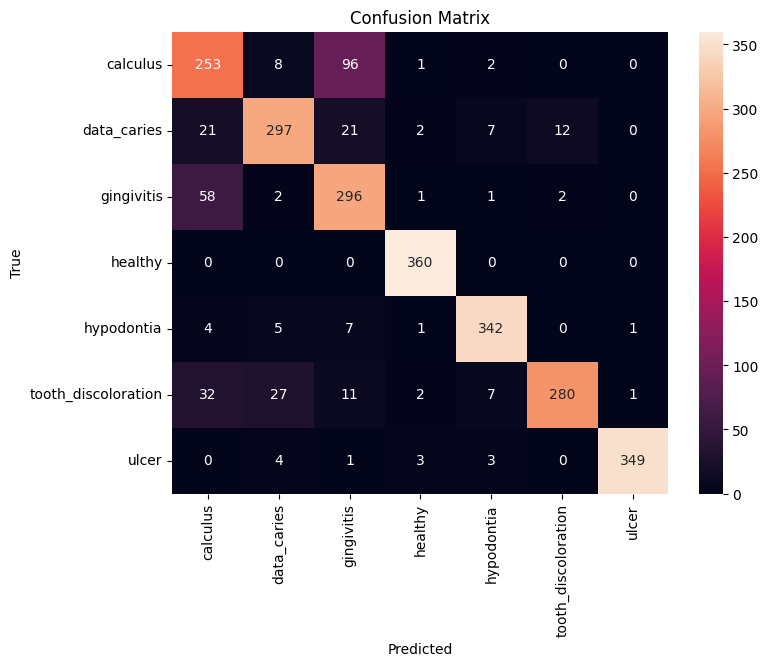

Overall ROC-AUC: 0.9872186397707231
calculus Accuracy: 0.7028
data_caries Accuracy: 0.8250
gingivitis Accuracy: 0.8222
healthy Accuracy: 1.0000
hypodontia Accuracy: 0.9500
tooth_discoloration Accuracy: 0.7778
ulcer Accuracy: 0.9694

Ulcer Recall (Critical Class): 0.9694444444444444

Pipeline completed successfully.


In [40]:
# =========================================================
# ORAL DISEASE 7-CLASS TRAINING PIPELINE (FINAL CLEAN)
# =========================================================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# =========================================================
# 1️⃣ ENVIRONMENT CHECK
# =========================================================

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# =========================================================
# 2️⃣ CONFIGURATION
# =========================================================

BASE_PATH = r"E:\Final Project\Final_Dataset\oral\disease_classification"

WEIGHTS_PATH = "oral7_best_weights.h5"
FINAL_MODEL_PATH = "oral7_best_model.keras"
FINAL_MODEL_PATH_H5 = "oral7_best_model.h5"

IMG_SIZE = (224, 224)
BATCH_SIZE = 8
PHASE1_EPOCHS = 6
PHASE2_EPOCHS = 10

AUTOTUNE = tf.data.AUTOTUNE

# =========================================================
# 3️⃣ DATASET VERIFICATION
# =========================================================

def verify_dataset(base_path):
    print("\nVerifying dataset structure...\n")
    for split in ["train", "val", "test"]:
        split_path = os.path.join(base_path, split)
        if not os.path.exists(split_path):
            raise ValueError(f"{split} folder missing!")

        classes = sorted(os.listdir(split_path))
        print(f"{split.upper()} classes:", classes)

        for cls in classes:
            cls_path = os.path.join(split_path, cls)
            print(f"{split}/{cls} → {len(os.listdir(cls_path))} images")

    print("\nDataset verified successfully.\n")

verify_dataset(BASE_PATH)

# =========================================================
# 4️⃣ LOAD DATASETS
# =========================================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_PATH, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("\nDetected Classes:", class_names)
print("Total Classes:", num_classes)

if num_classes != 7:
    raise ValueError("Expected exactly 7 classes.")

# =========================================================
# 5️⃣ DATA AUGMENTATION + PREPROCESSING
# =========================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

def prepare(ds, training=False):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y),
                    num_parallel_calls=AUTOTUNE)

    ds = ds.map(lambda x, y: (preprocess_input(x), y),
                num_parallel_calls=AUTOTUNE)

    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

# =========================================================
# 6️⃣ BUILD MODEL
# =========================================================

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

# =========================================================
# 7️⃣ LOAD PREVIOUS BEST WEIGHTS (IF EXISTS)
# =========================================================

if os.path.exists(WEIGHTS_PATH):
    print("Loading previous best weights...")
    model.load_weights(WEIGHTS_PATH)
    print("Weights loaded successfully.")
else:
    print("No previous weights found. Training from scratch.")

# =========================================================
# 8️⃣ CALLBACKS
# =========================================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    WEIGHTS_PATH,
    monitor="val_accuracy",
    save_best_only=True,
    save_weights_only=True,
    mode="max",
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=4,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]

# =========================================================
# 9️⃣ PHASE 1 TRAINING
# =========================================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting Phase 1 Training...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE1_EPOCHS,
    callbacks=callbacks
)

# =========================================================
# 🔟 PHASE 2 FINE-TUNING
# =========================================================

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nStarting Phase 2 Fine-Tuning...")
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks
)

# =========================================================
# 1️⃣1️⃣ SAVE FINAL MODEL
# =========================================================

model.save(FINAL_MODEL_PATH)
model.save(FINAL_MODEL_PATH_H5)

print("Final models saved successfully.")



In [1]:
# =========================================================
# 1️⃣2️⃣ EVALUATION
# =========================================================

print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

# Collect predictions
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================================================
# 1️⃣3️⃣ CLASSIFICATION REPORT
# =========================================================

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================================================
# 1️⃣4️⃣ CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# 1️⃣5️⃣ ROC-AUC
# =========================================================

y_true_bin = label_binarize(y_true, classes=range(num_classes))
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')

print("Overall ROC-AUC:", roc_auc)

# =========================================================
# 1️⃣6️⃣ PER-CLASS ACCURACY
# =========================================================

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for idx, cls in enumerate(class_names):
    print(f"{cls} Accuracy: {per_class_acc[idx]:.4f}")

# =========================================================
# 1️⃣7️⃣ SPECIAL ULCER RECALL ANALYSIS
# =========================================================

if "ulcer" in class_names:
    ulcer_index = class_names.index("ulcer")
    ulcer_recall = cm[ulcer_index, ulcer_index] / cm[ulcer_index].sum()
    print("\nUlcer Recall (Critical Class):", ulcer_recall)

print("\nPipeline completed successfully.")



Evaluating on Test Set...


NameError: name 'model' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import label_binarize

print("\nEvaluating on Test Set...")
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

# =========================================================
# Collect predictions again (IMPORTANT after restart)
# =========================================================

y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# =========================================================
# Classification Report
# =========================================================

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# =========================================================
# Confusion Matrix (Blue Normal Style)
# =========================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
# cbar=False removes the color scale bar if you want an even cleaner look
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

# This specifically removes any remaining axis spines (borders)
sns.despine(left=True, bottom=True, top=True, right=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# ROC-AUC
# =========================================================

y_true_bin = label_binarize(y_true, classes=range(num_classes))
roc_auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
print("Overall ROC-AUC:", roc_auc)

# =========================================================
# Per-Class Accuracy
# =========================================================

per_class_acc = cm.diagonal() / cm.sum(axis=1)

for idx, cls in enumerate(class_names):
    print(f"{cls} Accuracy: {per_class_acc[idx]:.4f}")

# =========================================================
# Special Ulcer Recall
# =========================================================

if "ulcer" in class_names:
    ulcer_index = class_names.index("ulcer")
    ulcer_recall = cm[ulcer_index, ulcer_index] / cm[ulcer_index].sum()
    print("\nUlcer Recall (Critical Class):", ulcer_recall)

print("\nPipeline completed successfully.")


Evaluating on Test Set...
 47/315 [===>..........................] - ETA: 1:31 - loss: 0.5926 - accuracy: 0.7021

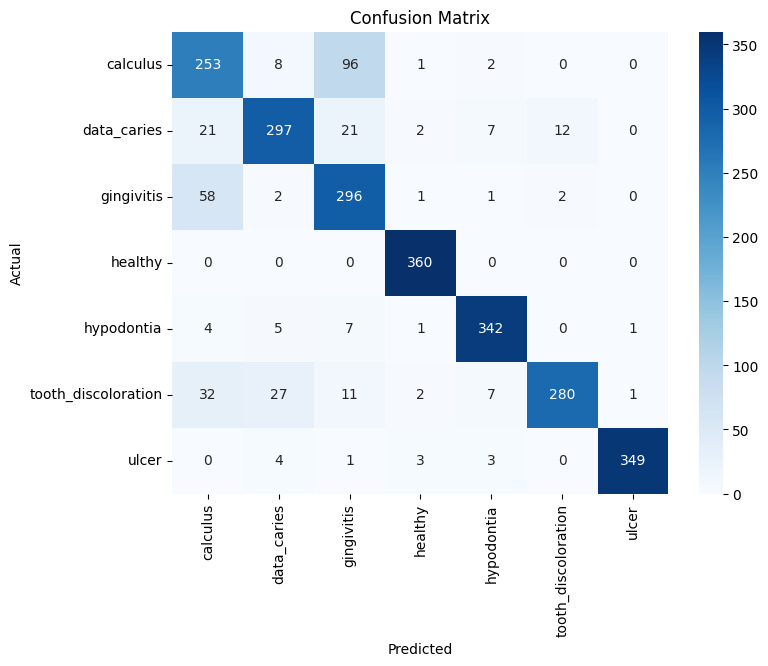

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
# cbar=False removes the color scale bar if you want an even cleaner look
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")

# This specifically removes any remaining axis spines (borders)
sns.despine(left=True, bottom=True, top=True, right=True)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()